# **Carregamento da Base**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")


df = pd.read_csv("/content/df_metadadosPericias.csv")

print("Dimensão da base:", df.shape)
print(df["requer_pericia"].value_counts())



Dimensão da base: (165499, 26)
requer_pericia
S    83939
N    81560
Name: count, dtype: int64


# **Preparação dos dados**

In [17]:
data = df.copy()

# Conversão das datas em atributos numéricos
for col in ["dt_primeira_distribuicao", "dt_inclusao"]:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors="coerce")

        data[col + "_ano"] = data[col].dt.year
        data[col + "_mes"] = data[col].dt.month
        data[col + "_dia_semana"] = data[col].dt.dayofweek

# Diferença entre datas
if "dt_primeira_distribuicao" in data.columns and "dt_inclusao" in data.columns:
    data["dias_entre_distribuicao_inclusao"] = (
        data["dt_inclusao"] - data["dt_primeira_distribuicao"]
    ).dt.days

## **Remoção de colunas**

In [18]:
# Colunas solicitadas
colunas_remover_solicitadas = [
    "ds_status_pericia_count",
    "ds_especialidade_count",
    "ds_complemento_especialidade_count",
    "id_perito_count"
]

# Colunas relacionadas diretamente à perícia
# São removidas para evitar vazamento de dados
colunas_vazamento = [
    "id_perito",
    "ds_especialidade",
    "ds_complemento_especialidade",
    "ds_status_pericia",
    "dt_cadastro_pericia",
    "dt_realizacao_pericia",
    "label_especialidade"
]

# Identificadores e colunas que não devem entrar no modelo
colunas_identificacao = [
    "index",
    "id_processo_judicial",
    "nr_processo_judicial"
]

# Datas originais, pois já criamos atributos derivados delas
colunas_datas_originais = [
    "dt_primeira_distribuicao",
    "dt_inclusao"
]

# Target
colunas_target = [
    "requer_pericia"
]

# Colunas constantes ou pouco úteis
colunas_outros = [
    "triagem_peticao"
]

colunas_remover = (
    colunas_remover_solicitadas
    + colunas_vazamento
    + colunas_identificacao
    + colunas_datas_originais
    + colunas_target
    + colunas_outros
)

# Alvo binário
y = data["requer_pericia"].astype(str).str.upper().map({
    "N": 0,
    "S": 1
})

# Atributos
X = data.drop(columns=[c for c in colunas_remover if c in data.columns])

print("Dimensão de X após remoções:", X.shape)
print("Colunas utilizadas:")
print(X.columns.tolist())

Dimensão de X após remoções: (165499, 19)
Colunas utilizadas:
['in_tutela_antecipada', 'nm_juizado', 'ds_cidade', 'codigo_assunto', 'ds_assunto_judicial', 'ds_complemento_assunto_judicial', 'detalhe_assunto_1', 'detalhe_assunto_2', 'ds_tipo_documento', 'ds_extensao', 'vara', 'tamanho_texto', 'dt_primeira_distribuicao_ano', 'dt_primeira_distribuicao_mes', 'dt_primeira_distribuicao_dia_semana', 'dt_inclusao_ano', 'dt_inclusao_mes', 'dt_inclusao_dia_semana', 'dias_entre_distribuicao_inclusao']


## **Separação de treino, validação e teste**

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (115849, 19)
Validação: (24825, 19)
Teste: (24825, 19)


## **Count encoding para variáveis categóricas**

In [20]:
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Essas colunas são numéricas, mas representam categorias
for col in ["codigo_assunto", "vara"]:
    if col in X_train.columns and col not in cat_cols:
        cat_cols.append(col)

num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Colunas categóricas:", cat_cols)
print("Colunas numéricas:", num_cols)


def aplicar_count_encoding(X_train, X_val, X_test, cat_cols, num_cols):
    X_train_enc = pd.DataFrame(index=X_train.index)
    X_val_enc = pd.DataFrame(index=X_val.index)
    X_test_enc = pd.DataFrame(index=X_test.index)

    # Tratamento das colunas numéricas
    medianas = X_train[num_cols].median(numeric_only=True)

    for col in num_cols:
        X_train_enc[col] = pd.to_numeric(X_train[col], errors="coerce").fillna(medianas[col])
        X_val_enc[col] = pd.to_numeric(X_val[col], errors="coerce").fillna(medianas[col])
        X_test_enc[col] = pd.to_numeric(X_test[col], errors="coerce").fillna(medianas[col])

    # Count encoding das colunas categóricas
    for col in cat_cols:
        contagens = (
            X_train[col]
            .fillna("DESCONHECIDO")
            .astype(str)
            .value_counts()
        )

        X_train_enc[col + "_count"] = (
            X_train[col]
            .fillna("DESCONHECIDO")
            .astype(str)
            .map(contagens)
            .fillna(0)
            .astype(float)
        )

        X_val_enc[col + "_count"] = (
            X_val[col]
            .fillna("DESCONHECIDO")
            .astype(str)
            .map(contagens)
            .fillna(0)
            .astype(float)
        )

        X_test_enc[col + "_count"] = (
            X_test[col]
            .fillna("DESCONHECIDO")
            .astype(str)
            .map(contagens)
            .fillna(0)
            .astype(float)
        )

    return X_train_enc, X_val_enc, X_test_enc


X_train_enc, X_val_enc, X_test_enc = aplicar_count_encoding(
    X_train,
    X_val,
    X_test,
    cat_cols,
    num_cols
)

print("Base final de treino:", X_train_enc.shape)
print("Features finais:")
print(X_train_enc.columns.tolist())

Colunas categóricas: ['in_tutela_antecipada', 'nm_juizado', 'ds_cidade', 'ds_assunto_judicial', 'ds_complemento_assunto_judicial', 'detalhe_assunto_1', 'detalhe_assunto_2', 'ds_tipo_documento', 'ds_extensao', 'codigo_assunto', 'vara']
Colunas numéricas: ['tamanho_texto', 'dt_primeira_distribuicao_ano', 'dt_primeira_distribuicao_mes', 'dt_primeira_distribuicao_dia_semana', 'dt_inclusao_ano', 'dt_inclusao_mes', 'dt_inclusao_dia_semana', 'dias_entre_distribuicao_inclusao']
Base final de treino: (115849, 19)
Features finais:
['tamanho_texto', 'dt_primeira_distribuicao_ano', 'dt_primeira_distribuicao_mes', 'dt_primeira_distribuicao_dia_semana', 'dt_inclusao_ano', 'dt_inclusao_mes', 'dt_inclusao_dia_semana', 'dias_entre_distribuicao_inclusao', 'in_tutela_antecipada_count', 'nm_juizado_count', 'ds_cidade_count', 'ds_assunto_judicial_count', 'ds_complemento_assunto_judicial_count', 'detalhe_assunto_1_count', 'detalhe_assunto_2_count', 'ds_tipo_documento_count', 'ds_extensao_count', 'codigo_ass

## **Função de métricas**



In [21]:
def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "logloss": log_loss(y_true, np.column_stack([1 - y_proba, y_proba]))
    }

[texto do link](https://)## **Relatório do melhor modelo binário**

Treinando Random Forest com 10 árvores...
Treinando Random Forest com 25 árvores...
Treinando Random Forest com 50 árvores...
Treinando Random Forest com 100 árvores...
Treinando Random Forest com 150 árvores...
Treinando Random Forest com 200 árvores...


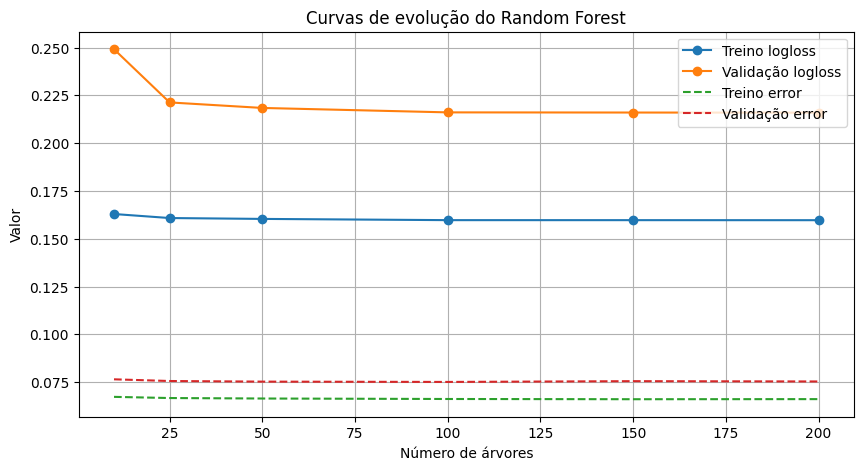

In [22]:
n_estimators_curve = [10, 25, 50, 100, 150, 200]

evolucao = []

for n in n_estimators_curve:
    print(f"Treinando Random Forest com {n} árvores...")

    rf_temp = RandomForestClassifier(
        n_estimators=n,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )

    rf_temp.fit(X_train_enc, y_train)

    # Treino
    y_train_pred = rf_temp.predict(X_train_enc)
    y_train_proba = rf_temp.predict_proba(X_train_enc)[:, 1]

    # Validação
    y_val_pred = rf_temp.predict(X_val_enc)
    y_val_proba = rf_temp.predict_proba(X_val_enc)[:, 1]

    evolucao.append({
        "n_arvores": n,
        "treino_logloss": log_loss(y_train, rf_temp.predict_proba(X_train_enc)),
        "validacao_logloss": log_loss(y_val, rf_temp.predict_proba(X_val_enc)),
        "treino_error": 1 - accuracy_score(y_train, y_train_pred),
        "validacao_error": 1 - accuracy_score(y_val, y_val_pred)
    })

evolucao_df = pd.DataFrame(evolucao)

plt.figure(figsize=(10, 5))
plt.plot(
    evolucao_df["n_arvores"],
    evolucao_df["treino_logloss"],
    label="Treino logloss",
    marker="o"
)
plt.plot(
    evolucao_df["n_arvores"],
    evolucao_df["validacao_logloss"],
    label="Validação logloss",
    marker="o"
)
plt.plot(
    evolucao_df["n_arvores"],
    evolucao_df["treino_error"],
    label="Treino error",
    linestyle="--"
)
plt.plot(
    evolucao_df["n_arvores"],
    evolucao_df["validacao_error"],
    label="Validação error",
    linestyle="--"
)

plt.xlabel("Número de árvores")
plt.ylabel("Valor")
plt.title("Curvas de evolução do Random Forest")
plt.legend()
plt.grid(True)
plt.show()

## **Treinamento do modelo final**

In [23]:
model = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_enc, y_train)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=5,
                       n_jobs=-1, random_state=42)

Foi escolhido `n_estimators=100` porque 100 árvores normalmente oferecem bom equilíbrio entre desempenho e custo computacional.

## **Predições**

In [24]:
y_train_pred = model.predict(X_train_enc)
y_val_pred = model.predict(X_val_enc)
y_test_pred = model.predict(X_test_enc)

y_train_proba = model.predict_proba(X_train_enc)[:, 1]
y_val_proba = model.predict_proba(X_val_enc)[:, 1]
y_test_proba = model.predict_proba(X_test_enc)[:, 1]

## **Métricas por conjunto**



           accuracy  precision    recall  f1_score  balanced_accuracy  \
Treino     0.933836   0.912112  0.962268  0.936519           0.933422   
Validação  0.924914   0.906049  0.950520  0.927752           0.924541   
Teste      0.922739   0.901754  0.951314  0.925872           0.922322   

            roc_auc   logloss  
Treino     0.988236  0.159720  
Validação  0.963965  0.216095  
Teste      0.960895  0.223490  


<Figure size 1000x600 with 0 Axes>

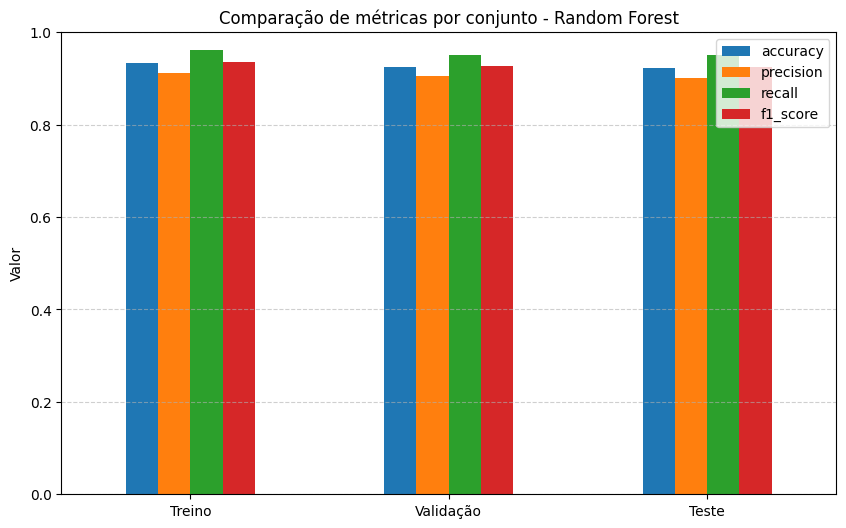

In [25]:
metrics_summary = {
    "Treino": compute_metrics(y_train, y_train_pred, y_train_proba),
    "Validação": compute_metrics(y_val, y_val_pred, y_val_proba),
    "Teste": compute_metrics(y_test, y_test_pred, y_test_proba)
}

metrics_df = pd.DataFrame(metrics_summary).T

print(metrics_df)

plt.figure(figsize=(10, 6))
metrics_df[["accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Comparação de métricas por conjunto - Random Forest")
plt.ylim(0, 1)
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## **Matriz de confusão**

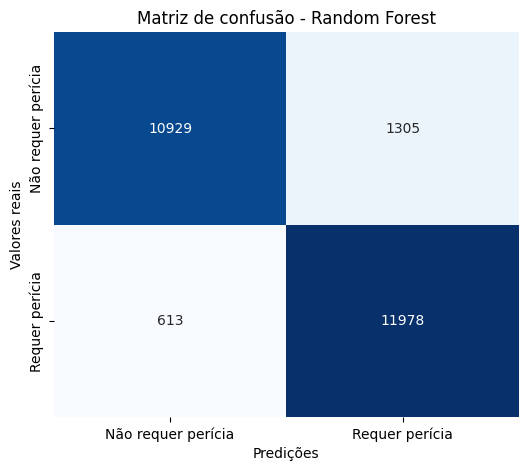

Relatório de classificação - Teste
                    precision    recall  f1-score   support

Não requer perícia       0.95      0.89      0.92     12234
    Requer perícia       0.90      0.95      0.93     12591

          accuracy                           0.92     24825
         macro avg       0.92      0.92      0.92     24825
      weighted avg       0.92      0.92      0.92     24825



In [26]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Não requer perícia", "Requer perícia"],
    yticklabels=["Não requer perícia", "Requer perícia"]
)
plt.title("Matriz de confusão - Random Forest")
plt.xlabel("Predições")
plt.ylabel("Valores reais")
plt.show()

print("Relatório de classificação - Teste")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Não requer perícia", "Requer perícia"],
        zero_division=0
    )
)

## Imporntancia das **variáveis**

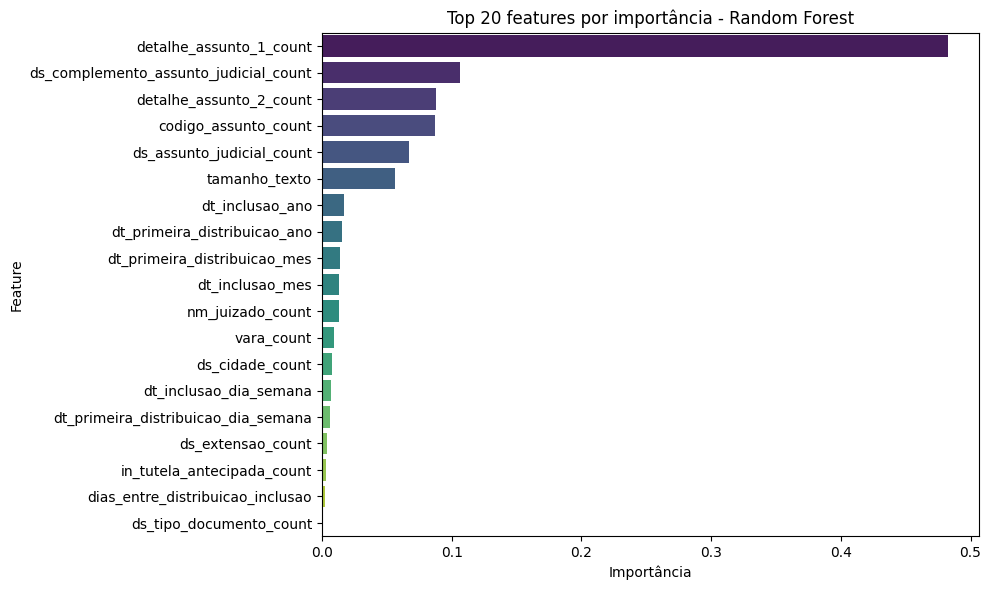

                                  feature  importancia
13                detalhe_assunto_1_count     0.482311
12  ds_complemento_assunto_judicial_count     0.106364
14                detalhe_assunto_2_count     0.088114
17                   codigo_assunto_count     0.086811
11              ds_assunto_judicial_count     0.067077
0                           tamanho_texto     0.056225
4                         dt_inclusao_ano     0.016803
1            dt_primeira_distribuicao_ano     0.015834
2            dt_primeira_distribuicao_mes     0.013645
5                         dt_inclusao_mes     0.013324
9                        nm_juizado_count     0.013106
18                             vara_count     0.009261
10                        ds_cidade_count     0.007767
6                  dt_inclusao_dia_semana     0.006895
3     dt_primeira_distribuicao_dia_semana     0.006412
16                      ds_extensao_count     0.004089
8              in_tutela_antecipada_count     0.003247
7        d

In [27]:
feature_importance = pd.DataFrame({
    "feature": X_train_enc.columns,
    "importancia": model.feature_importances_
}).sort_values("importancia", ascending=False)

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="importancia",
    y="feature",
    data=top_features,
    hue="feature",
    palette="viridis",
    legend=False
)
plt.title("Top 20 features por importância - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(top_features)